# Strategy A: inverse design with formulation-wise validation

This notebook implements the classification--regression workflow used to infer the PLA-based material family and filler content from target flexural properties.

The dataset contains 60 specimen-level measurements from six formulations. The input features are flexural modulus, flexural strength, and strain at break. Two validation views are reported:

- **Specimen-wise cross-validation**, retained as a within-domain reference. Replicates of the same formulation may appear in both training and validation subsets, so these scores can be optimistic.
- **Leave-One-Formulation-Out (LOFO) validation**, in which all specimens from one formulation are excluded from training and used only for testing.

Strict continuous LOFO regression is identifiable for the MW family, which contains three non-zero concentration levels. It is not identifiable for OW, which contains only two non-zero levels. Random seeds are fixed for reproducibility.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_predict,
    cross_val_score,
    learning_curve
)
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
%pip install -q imbalanced-learn openpyxl

In [4]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [5]:
from pathlib import Path

candidate_paths = [
    Path("../dataset/dataset_additives.xlsx"),
    Path("dataset/dataset_additives.xlsx"),
    Path("dataset_additives.xlsx"),
    Path("/content/dataset_additives.xlsx"),
]

dataset_path = next((path for path in candidate_paths if path.exists()), None)

if dataset_path is None:
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError(
            "dataset_additives.xlsx was not found. Place it beside the notebook "
            "or in a dataset/ subdirectory."
        ) from exc

    print("Dataset not found. Please upload dataset_additives.xlsx.")
    uploaded = files.upload()
    dataset_path = Path(next(iter(uploaded)))

print(f"Using dataset: {dataset_path}")

Dataset not found. Please upload dataset_additives.xlsx.


Saving dataset_additives (7).xlsx to dataset_additives (7).xlsx
Using dataset: dataset_additives (7).xlsx


In [6]:
df = pd.read_excel(dataset_path, keep_default_na=False)

# Normalize the public dataset column names used by the analysis.
column_map = {
    "material": "material",
    "percentage (%)": "percentage",
    "flexural_modulus (GPa)": "flexural_modulus",
    "flexural_strength_at_break (MPa)": "flexural_strength",
    "strain_at_break (%)": "strain_at_break",
}

missing_columns = [name for name in column_map if name not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required dataset columns: {missing_columns}")

df = df.rename(columns=column_map)[list(column_map.values())]

for column in ["percentage", "flexural_modulus", "flexural_strength", "strain_at_break"]:
    df[column] = (
        df[column]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

df["material"] = df["material"].astype(str).str.strip().str.upper()

print(df.head())
print("\nDataset shape:", df.shape)
print("\nMaterial families:", df["material"].unique())
print("\nSpecimen count by material family:")
print(df["material"].value_counts(dropna=False))

  material  percentage  flexural_modulus  flexural_strength  strain_at_break
0       NA         0.0              3.74             103.95             4.18
1       NA         0.0              3.69              99.88             3.83
2       NA         0.0              3.54             103.76             4.11
3       NA         0.0              3.80             104.76             4.86
4       NA         0.0              3.95             100.34             3.86

Dataset shape: (60, 5)

Material families: ['NA' 'MW' 'OW']

Specimen count by material family:
material
MW    30
OW    20
NA    10
Name: count, dtype: int64


In [7]:
FEATURES = ["flexural_modulus", "flexural_strength", "strain_at_break"]

print("Model features:", FEATURES)
print("\nAvailable filler levels by material family:")
print(df.groupby("material")["percentage"].unique())

Model features: ['flexural_modulus', 'flexural_strength', 'strain_at_break']

Available filler levels by material family:
material
MW    [10.0, 20.0, 30.0]
NA                 [0.0]
OW          [10.0, 20.0]
Name: percentage, dtype: object


In [8]:
X_class = df[["flexural_modulus", "flexural_strength", "strain_at_break"]].copy()
y_class = df["material"].copy()

label_encoder = LabelEncoder()
y_class_enc = label_encoder.fit_transform(y_class)

print("Class mapping:")
for cls, code in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{cls} -> {code}")

Class mapping:
MW -> 0
NA -> 1
OW -> 2


In [9]:
# Specimen-wise splitting is retained only as a within-domain reference.
# Replicates from the same formulation may occur in both subsets.
X_train, X_test, y_train, y_test = train_test_split(
    X_class,
    y_class_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_class_enc,
)

In [10]:
# SMOTE requires fewer neighbors than the smallest class in each training split.

from sklearn.model_selection import StratifiedKFold
from collections import Counter

class_counts = Counter(y_train)
min_class_count = min(class_counts.values())

print("Class counts in y_train:", class_counts)
print("Minimum class count:", min_class_count)


smote_k = max(1, min(3, min_class_count - 1))
print("Selected SMOTE k_neighbors:", smote_k)

classification_models = {
    "RandomForestClassifier_SMOTE": ImbPipeline([
        ("smote", SMOTE(random_state=42, k_neighbors=smote_k)),
        ("model", RandomForestClassifier(
            n_estimators=150,
            max_depth=4,
            min_samples_leaf=3,
            min_samples_split=6,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "LogisticRegression_SMOTE": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42, k_neighbors=smote_k)),
        ("model", LogisticRegression(
            C=0.5,
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "SVC_SMOTE": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42, k_neighbors=smote_k)),
        ("model", SVC(
            C=0.7,
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ])
}

Class counts in y_train: Counter({np.int64(0): 24, np.int64(2): 16, np.int64(1): 8})
Minimum class count: 8
Selected SMOTE k_neighbors: 3


In [11]:
# Compare classifiers using stratified cross-validation within the training subset.

classification_results = []
trained_classifiers = {}

best_clf_name = None
best_clf_model = None
best_clf_score = -np.inf
best_y_pred = None

print("=== CLASSIFICATION MODELS ===")

# Stratification preserves class proportions across folds.
n_splits_clf = max(2, min(5, min_class_count))
cv = StratifiedKFold(n_splits=n_splits_clf, shuffle=True, random_state=42)

print("Number of classification folds:", n_splits_clf)

for name, base_model in classification_models.items():
    model = clone(base_model)

    try:
        cv_scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="accuracy",
            error_score=np.nan
        )
        cv_acc = np.nanmean(cv_scores)

        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        train_acc = accuracy_score(y_train, train_pred)
        test_acc = accuracy_score(y_test, test_pred)

        gap = train_acc - cv_acc if not np.isnan(cv_acc) else np.nan
        penalized_score = cv_acc - abs(gap) * 0.5 if not np.isnan(gap) else -np.inf

        print(
            f"{name:30} -> CV Acc = {cv_acc:.4f} | "
            f"Train Acc = {train_acc:.4f} | Test Acc = {test_acc:.4f} | "
            f"Gap = {gap:.4f} | Penalized = {penalized_score:.4f}"
        )

        classification_results.append({
            "classifier": name,
            "cv_accuracy": cv_acc,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc,
            "gap": gap,
            "penalized_score": penalized_score
        })

        trained_classifiers[name] = model

        if penalized_score > best_clf_score:
            best_clf_score = penalized_score
            best_clf_name = name
            best_clf_model = model
            best_y_pred = test_pred

    except Exception as e:
        print(f"{name:30} -> ERROR: {e}")

classification_results_df = pd.DataFrame(classification_results)

if not classification_results_df.empty:
    classification_results_df = classification_results_df.sort_values(
        "penalized_score", ascending=False
    )

print("\nBEST CLASSIFIER:", best_clf_name)
print(f"Best penalized score: {best_clf_score:.4f}")

classification_results_df

=== CLASSIFICATION MODELS ===
Number of classification folds: 5
RandomForestClassifier_SMOTE   -> CV Acc = 0.9800 | Train Acc = 1.0000 | Test Acc = 0.9167 | Gap = 0.0200 | Penalized = 0.9700
LogisticRegression_SMOTE       -> CV Acc = 0.9800 | Train Acc = 1.0000 | Test Acc = 1.0000 | Gap = 0.0200 | Penalized = 0.9700
SVC_SMOTE                      -> CV Acc = 1.0000 | Train Acc = 1.0000 | Test Acc = 1.0000 | Gap = 0.0000 | Penalized = 1.0000

BEST CLASSIFIER: SVC_SMOTE
Best penalized score: 1.0000


,classifier,cv_accuracy,train_accuracy,test_accuracy,gap,penalized_score
2,SVC_SMOTE,1.00,1.0,1.000000,0.00,1.00
0,RandomForestClassifier_SMOTE,0.98,1.0,0.916667,0.02,0.97
1,LogisticRegression_SMOTE,0.98,1.0,1.000000,0.02,0.97


=== CONFUSION MATRIX ===

Confusion matrix values:
[[6 0 0]
 [0 2 0]
 [0 0 4]]


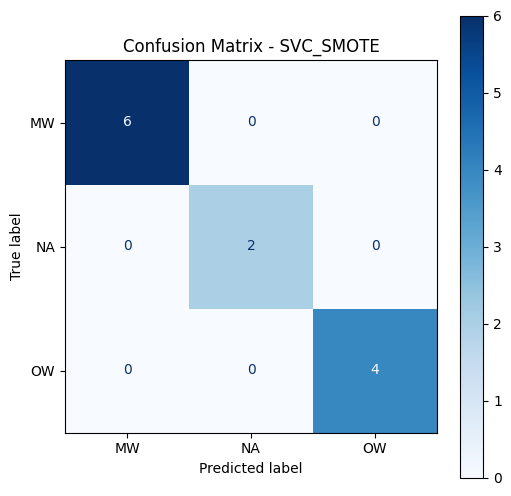

In [12]:
print("=== CONFUSION MATRIX ===")

if best_y_pred is None:
    print("No valid classifier is available.")
else:
    y_test_arr = np.asarray(y_test).ravel().astype(int)
    best_y_pred_arr = np.asarray(best_y_pred).ravel().astype(int)

    labels = list(range(len(label_encoder.classes_)))
    class_names = [str(x) for x in label_encoder.classes_]

    cm = confusion_matrix(
        y_test_arr,
        best_y_pred_arr,
        labels=labels
    )

    print("\nConfusion matrix values:")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix - {best_clf_name}")
    plt.show()

In [16]:
df_NA = df[df["material"] == "NA"].copy()
df_MW = df[df["material"] == "MW"].copy()
df_OW = df[df["material"] == "OW"].copy()

print("NA shape:", df_NA.shape)
print("MW shape:", df_MW.shape)
print("OW shape:", df_OW.shape)

NA shape: (10, 5)
MW shape: (30, 5)
OW shape: (20, 5)


In [17]:
regression_models = {
    "Linear": Pipeline([
        ("scaler", StandardScaler()),
        ("lin", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=3.0))
    ]),

    "Polynomial": Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("ridge", Ridge(alpha=8.0))
    ]),

    "RandomForest": RandomForestRegressor(
        n_estimators=150,
        max_depth=4,
        min_samples_leaf=4,
        min_samples_split=8,
        max_features="sqrt",
        random_state=42
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=80,
        learning_rate=0.03,
        max_depth=2,
        min_samples_leaf=3,
        subsample=0.85,
        random_state=42
    )
}

In [18]:
# Fit family-specific regressors and generate specimen-wise out-of-fold predictions.

datasets_by_material = {
    "MW": df_MW,
    "OW": df_OW
}

trained_regressors = {}
regression_metrics = {}
best_regressor_name = {}

for material_name, df_sub in datasets_by_material.items():

    print(f"\n==============================")
    print(f"REGRESSION FOR MATERIAL: {material_name}")
    print(f"==============================")

    trained_regressors[material_name] = {}
    regression_metrics[material_name] = []

    X_sub = df_sub[["flexural_modulus", "flexural_strength", "strain_at_break"]].copy()
    y_sub = df_sub["percentage"].copy()

    best_rmse = np.inf
    best_name = None

    for model_name, base_model in regression_models.items():

        cv_model = clone(base_model)

        kf = KFold(
            n_splits=min(5, len(X_sub)),
            shuffle=True,
            random_state=42
        )

        preds = cross_val_predict(cv_model, X_sub, y_sub, cv=kf)

        rmse = np.sqrt(mean_squared_error(y_sub, preds))
        mae = mean_absolute_error(y_sub, preds)
        r2 = r2_score(y_sub, preds)

        # final model fitted to the complete material-family subset
        final_model = clone(base_model)
        final_model.fit(X_sub, y_sub)
        trained_regressors[material_name][model_name] = final_model

        train_pred = final_model.predict(X_sub)
        train_rmse = np.sqrt(mean_squared_error(y_sub, train_pred))
        gap = rmse - train_rmse
        gap_rel = gap / rmse if rmse > 0 else np.nan

        regression_metrics[material_name].append({
            "model": model_name,
            "rmse": rmse,
            "mae": mae,
            "r2": r2,
            "train_rmse": train_rmse,
            "gap": gap,
            "gap_rel": gap_rel
        })

        print(
            f"{model_name:20} -> RMSE={rmse:.2f} | MAE={mae:.2f} | "
            f"R2={r2:.3f} | Train_RMSE={train_rmse:.2f} | "
            f"Gap={gap:.2f} | Gap_rel={100*gap_rel:.1f}%"
        )

        # primary selection criterion: cross-validated RMSE
        if rmse < best_rmse:
            best_rmse = rmse
            best_name = model_name

    # tie-break: if models are close, prefer the smaller train-validation gap
    metrics_df = pd.DataFrame(regression_metrics[material_name]).sort_values("rmse")
    best_rmse_value = metrics_df.iloc[0]["rmse"]
    tolerance = 0.10 * best_rmse_value  # 10% tolerance

    candidate_df = metrics_df[metrics_df["rmse"] <= best_rmse_value + tolerance]
    best_name = candidate_df.sort_values(["gap", "mae"]).iloc[0]["model"]

    best_regressor_name[material_name] = best_name

    selected_row = candidate_df.sort_values(["gap", "mae"]).iloc[0]
    print(
        f"\nBEST REGRESSOR for {material_name}: {best_name} "
        f"(RMSE={selected_row['rmse']:.2f}, Gap={selected_row['gap']:.2f})"
    )


REGRESSION FOR MATERIAL: MW
Linear               -> RMSE=1.50 | MAE=1.24 | R2=0.966 | Train_RMSE=1.37 | Gap=0.13 | Gap_rel=8.6%
Ridge                -> RMSE=1.60 | MAE=1.33 | R2=0.962 | Train_RMSE=1.47 | Gap=0.13 | Gap_rel=8.2%
Polynomial           -> RMSE=1.74 | MAE=1.23 | R2=0.955 | Train_RMSE=1.46 | Gap=0.28 | Gap_rel=16.0%
RandomForest         -> RMSE=1.71 | MAE=1.30 | R2=0.956 | Train_RMSE=0.55 | Gap=1.17 | Gap_rel=68.2%
GradientBoosting     -> RMSE=1.64 | MAE=1.20 | R2=0.959 | Train_RMSE=0.74 | Gap=0.91 | Gap_rel=55.1%

BEST REGRESSOR for MW: Linear (RMSE=1.50, Gap=0.13)

REGRESSION FOR MATERIAL: OW
Linear               -> RMSE=0.52 | MAE=0.42 | R2=0.989 | Train_RMSE=0.42 | Gap=0.10 | Gap_rel=19.0%
Ridge                -> RMSE=1.25 | MAE=1.11 | R2=0.937 | Train_RMSE=0.87 | Gap=0.38 | Gap_rel=30.3%
Polynomial           -> RMSE=1.42 | MAE=1.26 | R2=0.920 | Train_RMSE=1.15 | Gap=0.27 | Gap_rel=18.8%
RandomForest         -> RMSE=1.59 | MAE=1.52 | R2=0.899 | Train_RMSE=0.93 | Gap=0.6

In [19]:
all_regression_rows = []

for material_name, metrics_list in regression_metrics.items():
    for row in metrics_list:
        row_copy = row.copy()
        row_copy["material"] = material_name
        all_regression_rows.append(row_copy)

regression_summary_df = pd.DataFrame(all_regression_rows)
regression_summary_df = regression_summary_df.sort_values(
    ["material", "rmse", "gap"],
    ascending=[True, True, True]
)

regression_summary_df

,model,rmse,mae,r2,train_rmse,gap,gap_rel,material
0,Linear,1.500572,1.238123,0.966224,1.370810,0.129762,0.086475,MW
1,Ridge,1.596501,1.334471,0.961768,1.465438,0.131063,0.082094,MW
4,GradientBoosting,1.644785,1.198431,0.959420,0.738919,0.905866,0.550751,MW
3,RandomForest,1.713310,1.296664,0.955969,0.545246,1.168065,0.681759,MW
2,Polynomial,1.735843,1.231014,0.954803,1.457993,0.277850,0.160066,MW
9,GradientBoosting,0.449358,0.448160,0.991923,0.437229,0.012129,0.026991,OW
5,Linear,0.524531,0.418612,0.988995,0.424776,0.099755,0.190179,OW
6,Ridge,1.250444,1.114278,0.937456,0.871259,0.379185,0.303241,OW
7,Polynomial,1.415130,1.256485,0.919896,1.149146,0.265984,0.187957,OW
8,RandomForest,1.590400,1.515757,0.898825,0.934249,0.656150,0.412569,OW


In [20]:
def plot_learning_curve_for_regressor(model, X, y, title):
    cv = KFold(
        n_splits=min(5, len(X)),
        shuffle=True,
        random_state=42
    )

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        train_sizes=np.linspace(0.4, 1.0, 5),
        n_jobs=None
    )

    train_rmse = -train_scores
    val_rmse = -val_scores

    train_mean = train_rmse.mean(axis=1)
    train_std = train_rmse.std(axis=1)

    val_mean = val_rmse.mean(axis=1)
    val_std = val_rmse.std(axis=1)

    plt.figure(figsize=(7, 5))
    plt.plot(train_sizes, train_mean, marker="o", label="Train RMSE")
    plt.plot(train_sizes, val_mean, marker="s", label="Validation RMSE")

    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2
    )
    plt.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.2
    )

    plt.xlabel("Training set size")
    plt.ylabel("RMSE")
    plt.title(title)
    plt.grid(True, linestyle=":")
    plt.legend()
    plt.show()

In [21]:
# Repeated cross-validation provides the variability of training and validation RMSE.

from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.base import clone
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np
import pandas as pd

# positive RMSE scorer; scikit-learn maximizes the negative score
rmse_scorer = make_scorer(
    lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    greater_is_better=False
)

overfitting_report = []

for material_name, df_sub in datasets_by_material.items():

    best_name = best_regressor_name[material_name]
    best_model = clone(regression_models[best_name])

    X_sub = df_sub[["flexural_modulus", "flexural_strength", "strain_at_break"]].copy()
    y_sub = df_sub["percentage"].copy()

    n_samples = len(X_sub)

    # use a valid number of folds for small subsets
    n_splits = min(5, max(2, n_samples))

    cv = RepeatedKFold(
        n_splits=n_splits,
        n_repeats=10,
        random_state=42
    )

    scores = cross_validate(
        best_model,
        X_sub,
        y_sub,
        cv=cv,
        scoring=rmse_scorer,
        return_train_score=True,
        n_jobs=-1
    )

    # convert the negative score back to positive RMSE
    train_rmse = -scores["train_score"]
    val_rmse   = -scores["test_score"]

    train_mean = train_rmse.mean()
    train_std  = train_rmse.std()

    val_mean = val_rmse.mean()
    val_std  = val_rmse.std()

    gap_abs = val_mean - train_mean
    gap_rel = gap_abs / val_mean if val_mean > 0 else np.nan

    target_range = y_sub.max() - y_sub.min()
    gap_norm_range = gap_abs / target_range if target_range > 0 else np.nan

    # overfitting diagnostic
    if gap_rel < 0.15:
        risk = "low"
    elif gap_rel < 0.30:
        risk = "moderate"
    else:
        risk = "high"

    # model stability diagnostic
    stability = val_std / val_mean if val_mean > 0 else np.nan

    if stability < 0.10:
        stability_label = "stable"
    elif stability < 0.25:
        stability_label = "moderate"
    else:
        stability_label = "unstable"

    overfitting_report.append({
        "material": material_name,
        "best_model": best_name,

        "train_rmse_mean": train_mean,
        "train_rmse_std": train_std,

        "cv_rmse_mean": val_mean,
        "cv_rmse_std": val_std,

        "gap_abs": gap_abs,
        "gap_rel": gap_rel,
        "gap_norm_range": gap_norm_range,

        "overfitting_risk": risk,
        "model_stability": stability_label
    })

overfitting_report_df = pd.DataFrame(overfitting_report)


overfitting_report_df = overfitting_report_df.sort_values(
    by=["overfitting_risk", "cv_rmse_mean"]
).reset_index(drop=True)

overfitting_report_df

,material,best_model,train_rmse_mean,train_rmse_std,cv_rmse_mean,cv_rmse_std,gap_abs,gap_rel,gap_norm_range,overfitting_risk,model_stability
0,OW,GradientBoosting,0.435148,0.007324,0.477840,0.081841,0.042693,0.089345,0.004269,low,moderate
1,MW,Linear,1.341181,0.092628,1.564043,0.390016,0.222862,0.142491,0.011143,low,moderate



Learning curve - MW - Linear


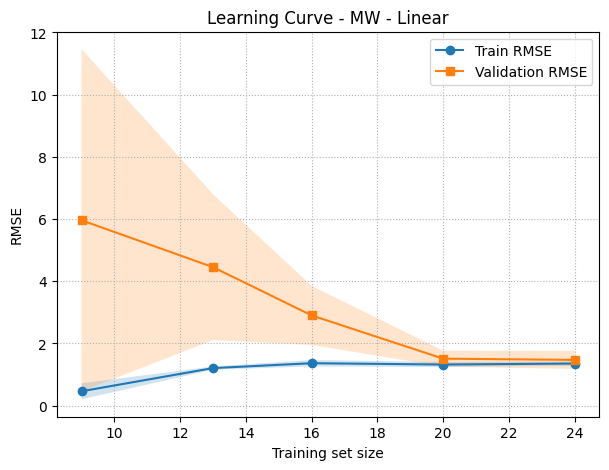


Learning curve - OW - GradientBoosting


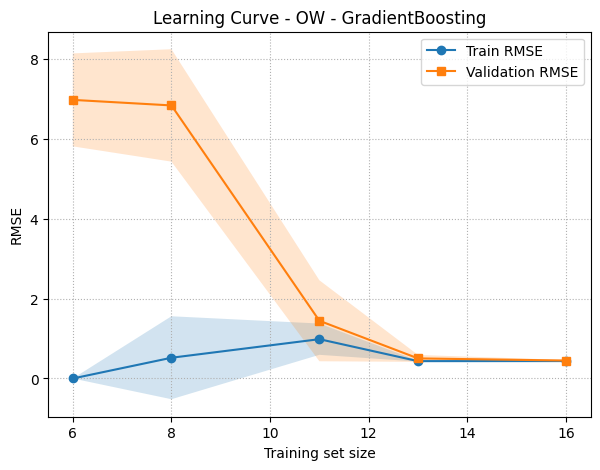

In [22]:
for material_name, df_sub in datasets_by_material.items():
    best_name = best_regressor_name[material_name]
    best_model = clone(regression_models[best_name])

    X_sub = df_sub[["flexural_modulus", "flexural_strength", "strain_at_break"]].copy()
    y_sub = df_sub["percentage"].copy()

    print(f"\nLearning curve - {material_name} - {best_name}")
    plot_learning_curve_for_regressor(
        best_model,
        X_sub,
        y_sub,
        title=f"Learning Curve - {material_name} - {best_name}"
    )

In [23]:
print("=== FINAL OVERFITTING CHECK ===")

for _, row in overfitting_report_df.iterrows():
    print(
        f"{row['material']} | {row['best_model']} | "
        f"train_RMSE={row['train_rmse_mean']:.3f} ± {row['train_rmse_std']:.3f} | "
        f"CV_RMSE={row['cv_rmse_mean']:.3f} ± {row['cv_rmse_std']:.3f} | "
        f"gap_abs={row['gap_abs']:.3f} | "
        f"gap_rel={100*row['gap_rel']:.1f}% | "
        f"gap/range={100*row['gap_norm_range']:.1f}% | "
        f"risk={row['overfitting_risk']} | "
        f"stability={row['model_stability']}"
    )

high_count = (overfitting_report_df["overfitting_risk"] == "high").sum()
moderate_count = (overfitting_report_df["overfitting_risk"] == "moderate").sum()

if high_count > 0:
    print("\nFINAL RESULT: at least one regressor shows a high overfitting risk.")
elif moderate_count > 0:
    print("\nFINAL RESULT: no severe overfitting signal, but at least one regressor shows moderate risk.")
else:
    print("\nFINAL RESULT: no strong overfitting signal detected.")

=== FINAL OVERFITTING CHECK ===
OW | GradientBoosting | train_RMSE=0.435 ± 0.007 | CV_RMSE=0.478 ± 0.082 | gap_abs=0.043 | gap_rel=8.9% | gap/range=0.4% | risk=low | stability=moderate
MW | Linear | train_RMSE=1.341 ± 0.093 | CV_RMSE=1.564 ± 0.390 | gap_abs=0.223 | gap_rel=14.2% | gap/range=1.1% | risk=low | stability=moderate

FINAL RESULT: no strong overfitting signal detected.


## Formulation-wise robustness analysis (LOFO)

The standard validation above is sample-wise: specimens belonging to the same material formulation can therefore appear in both training and validation subsets. To assess a stricter form of generalization, this section adds a **Leave-One-Formulation-Out (LOFO)** analysis.

A formulation is defined by the pair **material family + additive percentage**. For the material-classification stage, one composite formulation at a time (MW-10, MW-20, MW-30, OW-10, OW-20) is completely removed from training and then predicted. The neat-PLA formulation (`NA`, 0 wt.%) is not used as a held-out fold because removing it would eliminate the entire NA class from the training set; that would test unseen-class discovery rather than unseen-formulation generalization.

For the percentage-regression stage, a strict LOFO analysis is meaningful for **MW**, where three additive levels (10, 20, and 30 wt.%) are available. The reported $R^2$ is computed on the **pooled out-of-fold predictions**, not within each single held-out percentage, because the target is constant inside a LOFO fold.

In [24]:
# Formulation-wise material-family classification.

from sklearn.metrics import balanced_accuracy_score, f1_score

FEATURES_LOFO = ["flexural_modulus", "flexural_strength", "strain_at_break"]

# Unique formulation identifier: material family + additive percentage.
df_lofo = df.copy()
df_lofo["formulation"] = (
    df_lofo["material"].astype(str)
    + "_"
    + df_lofo["percentage"].astype(float).map(lambda x: f"{x:g}")
)

# Hold out only composite formulations. NA_0 remains in training because it is the
# only formulation representing the neat-PLA material class.
composite_formulations = sorted(
    df_lofo.loc[df_lofo["material"] != "NA", "formulation"].unique()
)

lofo_classification_rows = []
lofo_classification_fold_rows = []
lofo_classification_predictions = {}

mw_ow_codes = label_encoder.transform(["MW", "OW"])

for model_name, base_model in classification_models.items():
    y_true_all = []
    y_pred_all = []
    formulation_all = []

    for held_formulation in composite_formulations:
        train_mask = df_lofo["formulation"] != held_formulation
        test_mask = df_lofo["formulation"] == held_formulation

        X_tr = df_lofo.loc[train_mask, FEATURES_LOFO]
        y_tr = label_encoder.transform(df_lofo.loc[train_mask, "material"])
        X_te = df_lofo.loc[test_mask, FEATURES_LOFO]
        y_te = label_encoder.transform(df_lofo.loc[test_mask, "material"])

        model = clone(base_model)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        fold_acc = accuracy_score(y_te, y_pred)
        held_material = df_lofo.loc[test_mask, "material"].iloc[0]
        held_percentage = df_lofo.loc[test_mask, "percentage"].iloc[0]

        lofo_classification_fold_rows.append({
            "classifier": model_name,
            "held_formulation": held_formulation,
            "material": held_material,
            "percentage": held_percentage,
            "n_test": int(test_mask.sum()),
            "accuracy": fold_acc,
        })

        y_true_all.extend(y_te.tolist())
        y_pred_all.extend(np.asarray(y_pred).tolist())
        formulation_all.extend([held_formulation] * len(y_te))

    y_true_all = np.asarray(y_true_all, dtype=int)
    y_pred_all = np.asarray(y_pred_all, dtype=int)

    # Macro F1 is evaluated on the two material families that are actually held out.
    macro_f1 = f1_score(
        y_true_all,
        y_pred_all,
        labels=mw_ow_codes,
        average="macro",
        zero_division=0,
    )

    lofo_classification_rows.append({
        "classifier": model_name,
        "lofo_accuracy": accuracy_score(y_true_all, y_pred_all),
        "lofo_macro_f1_MW_OW": macro_f1,
    })

    lofo_classification_predictions[model_name] = {
        "y_true": y_true_all,
        "y_pred": y_pred_all,
        "formulation": np.asarray(formulation_all),
    }

lofo_classification_summary_df = (
    pd.DataFrame(lofo_classification_rows)
    .sort_values(["lofo_accuracy", "lofo_macro_f1_MW_OW"], ascending=False)
    .reset_index(drop=True)
)

lofo_classification_folds_df = pd.DataFrame(lofo_classification_fold_rows)

# Direct comparison with the standard sample-wise validation already computed above.
classification_standard_vs_lofo_df = (
    classification_results_df[["classifier", "cv_accuracy", "test_accuracy"]]
    .merge(lofo_classification_summary_df, on="classifier", how="inner")
    .sort_values("lofo_accuracy", ascending=False)
    .reset_index(drop=True)
)

print("=== STANDARD VALIDATION vs LOFO: MATERIAL CLASSIFICATION ===")
display(classification_standard_vs_lofo_df)

print("\n=== LOFO ACCURACY BY HELD-OUT FORMULATION ===")
display(
    lofo_classification_folds_df
    .pivot(index="held_formulation", columns="classifier", values="accuracy")
    .sort_index()
)

lofo_best_classifier_name = lofo_classification_summary_df.iloc[0]["classifier"]
print("\nBest LOFO classifier:", lofo_best_classifier_name)

=== STANDARD VALIDATION vs LOFO: MATERIAL CLASSIFICATION ===


,classifier,cv_accuracy,test_accuracy,lofo_accuracy,lofo_macro_f1_MW_OW
0,SVC_SMOTE,1.00,1.000000,0.96,0.970513
1,LogisticRegression_SMOTE,0.98,1.000000,0.88,0.921429
2,RandomForestClassifier_SMOTE,0.98,0.916667,0.76,0.764950



=== LOFO ACCURACY BY HELD-OUT FORMULATION ===


classifier,LogisticRegression_SMOTE,RandomForestClassifier_SMOTE,SVC_SMOTE
held_formulation,,,
MW_10,0.5,0.2,0.9
MW_20,1.0,1.0,1.0
MW_30,1.0,1.0,1.0
OW_10,0.9,0.6,0.9
OW_20,1.0,1.0,1.0



Best LOFO classifier: SVC_SMOTE


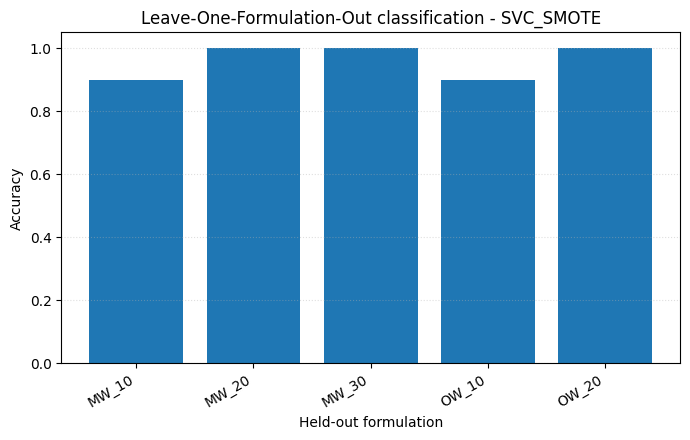

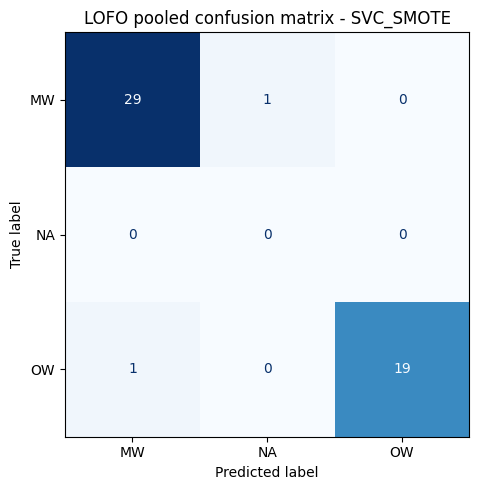

In [25]:
# Publication-oriented visualization of formulation-wise classification robustness.
best_lofo_folds = (
    lofo_classification_folds_df[
        lofo_classification_folds_df["classifier"] == lofo_best_classifier_name
    ]
    .sort_values(["material", "percentage"])
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(best_lofo_folds["held_formulation"], best_lofo_folds["accuracy"])
ax.set_ylim(0, 1.05)
ax.set_xlabel("Held-out formulation")
ax.set_ylabel("Accuracy")
ax.set_title(f"Leave-One-Formulation-Out classification - {lofo_best_classifier_name}")
ax.grid(True, axis="y", linestyle=":", alpha=0.4)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Pooled confusion matrix across all unseen composite formulations.
lofo_pred = lofo_classification_predictions[lofo_best_classifier_name]
all_codes = np.arange(len(label_encoder.classes_))
cm_lofo = confusion_matrix(
    lofo_pred["y_true"],
    lofo_pred["y_pred"],
    labels=all_codes,
)

fig, ax = plt.subplots(figsize=(5.5, 5.0))
ConfusionMatrixDisplay(
    confusion_matrix=cm_lofo,
    display_labels=label_encoder.classes_,
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"LOFO pooled confusion matrix - {lofo_best_classifier_name}")
plt.tight_layout()
plt.show()

### LOFO regression for the MW additive percentage

For PLA/MW composites, the model is trained on two percentage levels and tested on the third, repeating the procedure for 10, 20, and 30 wt.%. This is a strict test of prediction at a percentage level that is completely absent from training.

Because all specimens in a held-out fold have the same target percentage, a fold-wise $R^2$ is not informative. Therefore, MAE, RMSE, mean prediction and bias are reported for each held-out formulation, whereas $R^2$ is computed only after pooling all LOFO predictions.

In [26]:
# Strict LOFO regression for the MW concentration levels.

from sklearn.model_selection import LeaveOneGroupOut

X_mw_lofo = df_MW[FEATURES_LOFO].reset_index(drop=True)
y_mw_lofo = df_MW["percentage"].astype(float).reset_index(drop=True)
groups_mw_lofo = df_MW["percentage"].astype(str).reset_index(drop=True)

logo = LeaveOneGroupOut()

lofo_regression_rows = []
lofo_regression_fold_rows = []
lofo_regression_predictions = {}

for model_name, base_model in regression_models.items():
    oof_pred = np.full(len(X_mw_lofo), np.nan, dtype=float)

    for train_idx, test_idx in logo.split(X_mw_lofo, y_mw_lofo, groups=groups_mw_lofo):
        model = clone(base_model)
        model.fit(X_mw_lofo.iloc[train_idx], y_mw_lofo.iloc[train_idx])
        pred = np.asarray(model.predict(X_mw_lofo.iloc[test_idx]), dtype=float)
        oof_pred[test_idx] = pred

        held_percentage = float(y_mw_lofo.iloc[test_idx].iloc[0])
        y_fold = y_mw_lofo.iloc[test_idx].to_numpy(dtype=float)

        lofo_regression_fold_rows.append({
            "model": model_name,
            "held_percentage": held_percentage,
            "n_test": len(test_idx),
            "MAE": mean_absolute_error(y_fold, pred),
            "RMSE": np.sqrt(mean_squared_error(y_fold, pred)),
            "mean_prediction": float(np.mean(pred)),
            "bias": float(np.mean(pred - y_fold)),
        })

    lofo_regression_rows.append({
        "model": model_name,
        "LOFO_MAE": mean_absolute_error(y_mw_lofo, oof_pred),
        "LOFO_RMSE": np.sqrt(mean_squared_error(y_mw_lofo, oof_pred)),
        "LOFO_R2_pooled": r2_score(y_mw_lofo, oof_pred),
    })

    lofo_regression_predictions[model_name] = oof_pred

lofo_regression_summary_df = (
    pd.DataFrame(lofo_regression_rows)
    .sort_values(["LOFO_RMSE", "LOFO_MAE"])
    .reset_index(drop=True)
)
lofo_regression_folds_df = pd.DataFrame(lofo_regression_fold_rows)

print("=== MW REGRESSION: LOFO SUMMARY ===")
display(lofo_regression_summary_df)

best_mw_lofo_regressor = lofo_regression_summary_df.iloc[0]["model"]
print("Best MW LOFO regressor:", best_mw_lofo_regressor)

print("\n=== MW REGRESSION: ERROR BY HELD-OUT PERCENTAGE ===")
display(
    lofo_regression_folds_df[
        lofo_regression_folds_df["model"] == best_mw_lofo_regressor
    ].sort_values("held_percentage")
)

# Compare the original sample-wise CV with the stricter formulation-wise LOFO.
standard_mw = (
    regression_summary_df[regression_summary_df["material"] == "MW"]
    [["model", "rmse", "mae", "r2"]]
    .rename(columns={
        "rmse": "standard_CV_RMSE",
        "mae": "standard_CV_MAE",
        "r2": "standard_CV_R2",
    })
)

mw_standard_vs_lofo_df = (
    standard_mw
    .merge(lofo_regression_summary_df, on="model", how="inner")
    .sort_values("LOFO_RMSE")
    .reset_index(drop=True)
)

print("\n=== MW: STANDARD CV vs LOFO ===")
display(mw_standard_vs_lofo_df)

=== MW REGRESSION: LOFO SUMMARY ===


,model,LOFO_MAE,LOFO_RMSE,LOFO_R2_pooled
0,Ridge,4.464182,5.745841,0.504780
1,Polynomial,5.264904,5.943349,0.470149
2,Linear,5.825391,6.311217,0.402528
3,GradientBoosting,8.022216,9.058774,-0.230921
4,RandomForest,8.968501,10.141323,-0.542696


Best MW LOFO regressor: Ridge

=== MW REGRESSION: ERROR BY HELD-OUT PERCENTAGE ===


,model,held_percentage,n_test,MAE,RMSE,mean_prediction,bias
3,Ridge,10.0,10,9.192960,9.258118,19.192960,9.192960
4,Ridge,20.0,10,2.040313,2.765908,21.911083,1.911083
5,Ridge,30.0,10,2.159272,2.383496,27.840728,-2.159272



=== MW: STANDARD CV vs LOFO ===


,model,standard_CV_RMSE,standard_CV_MAE,standard_CV_R2,LOFO_MAE,LOFO_RMSE,LOFO_R2_pooled
0,Ridge,1.596501,1.334471,0.961768,4.464182,5.745841,0.504780
1,Polynomial,1.735843,1.231014,0.954803,5.264904,5.943349,0.470149
2,Linear,1.500572,1.238123,0.966224,5.825391,6.311217,0.402528
3,GradientBoosting,1.644785,1.198431,0.959420,8.022216,9.058774,-0.230921
4,RandomForest,1.713310,1.296664,0.955969,8.968501,10.141323,-0.542696


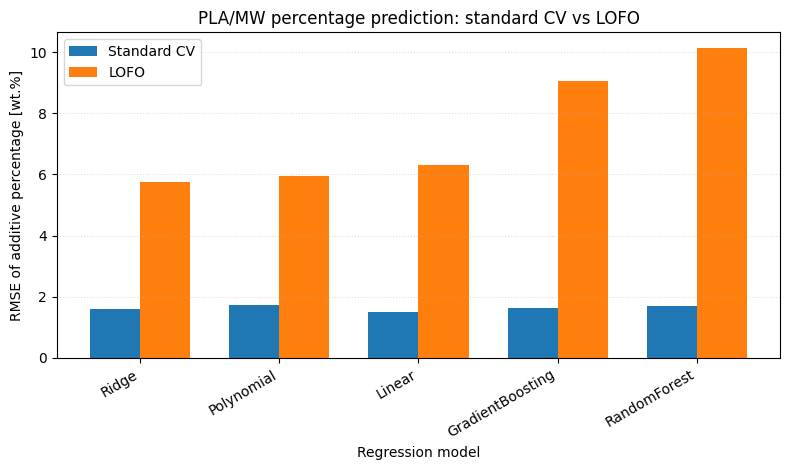

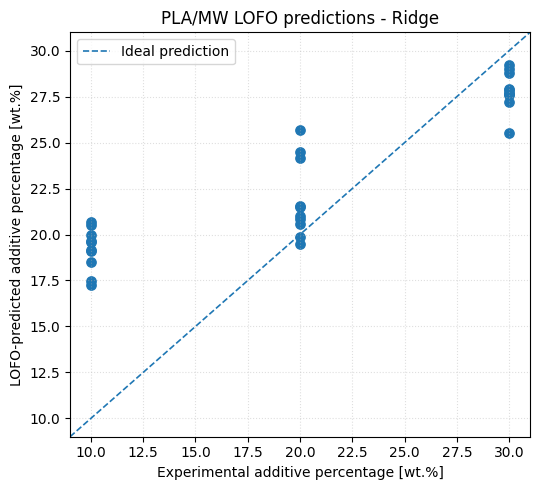

In [27]:
# Standard CV versus LOFO RMSE for MW.
plot_df = mw_standard_vs_lofo_df.sort_values("LOFO_RMSE").reset_index(drop=True)
x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(x - width/2, plot_df["standard_CV_RMSE"], width, label="Standard CV")
ax.bar(x + width/2, plot_df["LOFO_RMSE"], width, label="LOFO")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["model"], rotation=30, ha="right")
ax.set_ylabel("RMSE of additive percentage [wt.%]")
ax.set_xlabel("Regression model")
ax.set_title("PLA/MW percentage prediction: standard CV vs LOFO")
ax.grid(True, axis="y", linestyle=":", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

# Experimental versus LOFO prediction for the best MW model.
best_mw_oof = lofo_regression_predictions[best_mw_lofo_regressor]
fig, ax = plt.subplots(figsize=(5.5, 5.0))
ax.scatter(y_mw_lofo, best_mw_oof, s=45)
lims = [
    min(float(y_mw_lofo.min()), float(np.min(best_mw_oof))) - 1,
    max(float(y_mw_lofo.max()), float(np.max(best_mw_oof))) + 1,
]
ax.plot(lims, lims, "--", linewidth=1.2, label="Ideal prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Experimental additive percentage [wt.%]")
ax.set_ylabel("LOFO-predicted additive percentage [wt.%]")
ax.set_title(f"PLA/MW LOFO predictions - {best_mw_lofo_regressor}")
ax.grid(True, linestyle=":", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

### Why strict LOFO regression is not identifiable for OW

The OW subset contains only two target levels (10 and 20 wt.%). If one level is held out, the training set contains a **single remaining percentage value**, so a regression model cannot learn how the target changes with the mechanical properties. This is a limitation of the experimental design, not of the regression algorithm.

For this reason, the primary LOFO regression result is reported only for MW. The cell below makes this limitation explicit and prevents an apparently quantitative but scientifically misleading OW-LOFO score.

In [28]:
ow_levels = sorted(df_OW["percentage"].astype(float).unique())
print("Available OW percentage levels:", ow_levels)

if len(ow_levels) < 3:
    print(
        "Strict LOFO regression is not reported for OW: with only two percentage "
        "levels, holding one formulation out leaves a constant regression target in training."
    )
else:
    print("At least three OW levels are available; a strict LOFO regression can be performed.")

Available OW percentage levels: [np.float64(10.0), np.float64(20.0)]
Strict LOFO regression is not reported for OW: with only two percentage levels, holding one formulation out leaves a constant regression target in training.


### Sensitivity analysis: neat PLA as a 0 wt.% anchor for MW

As an **exploratory sensitivity analysis only**, neat PLA can be interpreted as the common $P=0$ endpoint of the PLA/MW composition path. The 0 wt.% observations are therefore kept as a physical anchor while MW-10, MW-20 and MW-30 are left out one at a time.

This anchored analysis is deliberately kept separate from the strict LOFO result and should not replace it in the main validation table.

In [29]:
# Optional sensitivity analysis using neat PLA as a 0 wt.% anchor.

# Optional anchored sensitivity analysis. It does NOT replace strict LOFO.
RUN_ZERO_ANCHOR_SENSITIVITY = True

if RUN_ZERO_ANCHOR_SENSITIVITY:
    df_mw_anchor = pd.concat([
        df_NA.assign(material="MW", percentage=0.0),
        df_MW.copy(),
    ], ignore_index=True)

    anchor_rows = []
    held_mw_percentages = sorted(df_MW["percentage"].astype(float).unique())

    for model_name, base_model in regression_models.items():
        y_true_all = []
        y_pred_all = []

        for held_percentage in held_mw_percentages:
            train_mask = df_mw_anchor["percentage"].astype(float) != held_percentage
            test_mask = df_mw_anchor["percentage"].astype(float) == held_percentage

            model = clone(base_model)
            model.fit(
                df_mw_anchor.loc[train_mask, FEATURES_LOFO],
                df_mw_anchor.loc[train_mask, "percentage"].astype(float),
            )
            pred = model.predict(df_mw_anchor.loc[test_mask, FEATURES_LOFO])

            y_true_all.extend(
                df_mw_anchor.loc[test_mask, "percentage"].astype(float).tolist()
            )
            y_pred_all.extend(np.asarray(pred, dtype=float).tolist())

        anchor_rows.append({
            "model": model_name,
            "anchor_MAE": mean_absolute_error(y_true_all, y_pred_all),
            "anchor_RMSE": np.sqrt(mean_squared_error(y_true_all, y_pred_all)),
            "anchor_R2_pooled": r2_score(y_true_all, y_pred_all),
        })

    mw_zero_anchor_sensitivity_df = (
        pd.DataFrame(anchor_rows)
        .sort_values(["anchor_RMSE", "anchor_MAE"])
        .reset_index(drop=True)
    )

    print("=== SENSITIVITY: MW LOFO WITH NEAT PLA AS 0 wt.% ANCHOR ===")
    display(mw_zero_anchor_sensitivity_df)

    print("\nStrict LOFO best result (primary):")
    display(lofo_regression_summary_df.head(1))
else:
    print("0 wt.% anchor sensitivity analysis disabled.")

=== SENSITIVITY: MW LOFO WITH NEAT PLA AS 0 wt.% ANCHOR ===


,model,anchor_MAE,anchor_RMSE,anchor_R2_pooled
0,Ridge,4.003449,4.501191,0.696089
1,Linear,4.959841,5.466166,0.551816
2,Polynomial,7.022699,7.795693,0.088408
3,GradientBoosting,9.312317,10.636587,-0.697055
4,RandomForest,10.771305,11.256655,-0.900684



Strict LOFO best result (primary):


,model,LOFO_MAE,LOFO_RMSE,LOFO_R2_pooled
0,Ridge,4.464182,5.745841,0.50478


---

## Additional robustness and applicability analyses

The following analyses add non-informative baselines, distinguish interpolation from extrapolation, report LOFO results by formulation, examine the closed-set limitation of Strategy B, and check whether an inverse-design target lies within the sampled mechanical-property domain.

In [30]:
# Add non-informative baselines to contextualize LOFO performance.

from sklearn.dummy import DummyRegressor, DummyClassifier



regression_models_lofo = dict(regression_models)
regression_models_lofo["Dummy_mean"] = DummyRegressor(strategy="mean")

classification_models_lofo = dict(classification_models)
classification_models_lofo["Dummy_most_frequent"] = DummyClassifier(strategy="most_frequent")

print("Regression models evaluated with LOFO:", list(regression_models_lofo))
print("Classification models evaluated with LOFO:", list(classification_models_lofo))

Regression models evaluated with LOFO: ['Linear', 'Ridge', 'Polynomial', 'RandomForest', 'GradientBoosting', 'Dummy_mean']
Classification models evaluated with LOFO: ['RandomForestClassifier_SMOTE', 'LogisticRegression_SMOTE', 'SVC_SMOTE', 'Dummy_most_frequent']


In [31]:
# Separate MW interpolation from boundary extrapolation and compare validation schemes.

from sklearn.model_selection import LeaveOneGroupOut

X_mw = df_MW[FEATURES].reset_index(drop=True)
y_mw = df_MW["percentage"].astype(float).reset_index(drop=True)
g_mw = y_mw.astype(str)

mw_levels = sorted(y_mw.unique())
INTERPOLATION_LEVELS = [lv for lv in mw_levels if min(mw_levels) < lv < max(mw_levels)]
print("MW levels:", mw_levels, "| interpolation fold:", INTERPOLATION_LEVELS)

rev_fold_rows, rev_summary_rows = [], []

for model_name, base_model in regression_models_lofo.items():
    oof = np.full(len(X_mw), np.nan)
    for tr, te in LeaveOneGroupOut().split(X_mw, y_mw, groups=g_mw):
        m = clone(base_model)
        m.fit(X_mw.iloc[tr], y_mw.iloc[tr])
        pred = np.asarray(m.predict(X_mw.iloc[te]), dtype=float)
        oof[te] = pred

        held = float(y_mw.iloc[te].iloc[0])
        rev_fold_rows.append({
            "model": model_name,
            "held_out_level_wt_pct": held,
            "regime": "interpolation" if held in INTERPOLATION_LEVELS else "extrapolation",
            "n_test": len(te),
            "MAE_wt_pct": mean_absolute_error(y_mw.iloc[te], pred),
            "mean_prediction_wt_pct": float(np.mean(pred)),
            "bias_wt_pct": float(np.mean(pred - y_mw.iloc[te].to_numpy())),
        })

    folds = pd.DataFrame([r for r in rev_fold_rows if r["model"] == model_name])
    rev_summary_rows.append({
        "model": model_name,
        "LOFO_MAE_all": mean_absolute_error(y_mw, oof),
        "LOFO_RMSE_all": np.sqrt(mean_squared_error(y_mw, oof)),
        "LOFO_R2_pooled": r2_score(y_mw, oof),
        "MAE_interpolation": folds.loc[folds.regime == "interpolation", "MAE_wt_pct"].mean(),
        "MAE_extrapolation": folds.loc[folds.regime == "extrapolation", "MAE_wt_pct"].mean(),
    })

rev_mw_folds_df = pd.DataFrame(rev_fold_rows).round(3)
rev_mw_summary_df = pd.DataFrame(rev_summary_rows).sort_values("LOFO_MAE_all").round(3)

print("\n=== MW LOFO: summary by model (MAE in filler percentage points) ===")
display(rev_mw_summary_df)

print("=== MW LOFO: fold-level results (excluding the dummy baseline) ===")
display(
    rev_mw_folds_df[rev_mw_folds_df.model != "Dummy_mean"]
    .pivot(index="model", columns="held_out_level_wt_pct", values="MAE_wt_pct")
)

rev_cv_vs_lofo_df = (
    regression_summary_df[regression_summary_df.material == "MW"][["model", "rmse", "r2"]]
    .rename(columns={"rmse": "CV_random_RMSE", "r2": "CV_random_R2"})
    .merge(rev_mw_summary_df[["model", "LOFO_RMSE_all", "LOFO_R2_pooled"]], on="model", how="right")
    .round(3)
)
print("=== MW: specimen-wise random CV versus formulation-wise LOFO ===")
display(rev_cv_vs_lofo_df)
print(
    "Specimen-wise validation gives optimistic and similar scores across models. "
    "Under LOFO, regularized linear models generalize better than tree ensembles. "
    "Model selection and reporting use the same three LOFO folds, so the selected score "
    "should still be interpreted cautiously."
)

MW levels: [np.float64(10.0), np.float64(20.0), np.float64(30.0)] | interpolation fold: [np.float64(20.0)]

=== MW LOFO: summary by model (MAE in filler percentage points) ===


,model,LOFO_MAE_all,LOFO_RMSE_all,LOFO_R2_pooled,MAE_interpolation,MAE_extrapolation
1,Ridge,4.464,5.746,0.505,2.040,5.676
2,Polynomial,5.265,5.943,0.470,4.154,5.820
0,Linear,5.825,6.311,0.403,3.214,7.131
4,GradientBoosting,8.022,9.059,-0.231,2.284,10.891
3,RandomForest,8.969,10.141,-0.543,2.495,12.205
5,Dummy_mean,10.000,12.247,-1.250,0.000,15.000


=== MW LOFO: fold-level results (excluding the dummy baseline) ===


held_out_level_wt_pct,10.0,20.0,30.0
model,,,
GradientBoosting,10.437,2.284,11.345
Linear,8.432,3.214,5.830
Polynomial,7.849,4.154,3.792
RandomForest,13.207,2.495,11.204
Ridge,9.193,2.040,2.159


=== MW: specimen-wise random CV versus formulation-wise LOFO ===


,model,CV_random_RMSE,CV_random_R2,LOFO_RMSE_all,LOFO_R2_pooled
0,Ridge,1.597,0.962,5.746,0.505
1,Polynomial,1.736,0.955,5.943,0.470
2,Linear,1.501,0.966,6.311,0.403
3,GradientBoosting,1.645,0.959,9.059,-0.231
4,RandomForest,1.713,0.956,10.141,-0.543
5,Dummy_mean,NaN,NaN,12.247,-1.250


Specimen-wise validation gives optimistic and similar scores across models. Under LOFO, regularized linear models generalize better than tree ensembles. Model selection and reporting use the same three LOFO folds, so the selected score should still be interpreted cautiously.


In [32]:
# Report material-family classification accuracy for each held-out formulation.

rev_clf_fold_rows = []

for model_name, base_model in classification_models_lofo.items():
    for held in composite_formulations:
        tr = df_lofo["formulation"] != held
        te = df_lofo["formulation"] == held

        m = clone(base_model)
        m.fit(df_lofo.loc[tr, FEATURES], label_encoder.transform(df_lofo.loc[tr, "material"]))
        pred = m.predict(df_lofo.loc[te, FEATURES])
        true = label_encoder.transform(df_lofo.loc[te, "material"])

        wrong = label_encoder.inverse_transform(pred[pred != true])
        rev_clf_fold_rows.append({
            "classifier": model_name,
            "held_formulation": held,
            "accuracy": accuracy_score(true, pred),
            "misassigned_to": ", ".join(sorted(set(wrong))) if len(wrong) else "-",
        })

rev_clf_folds_df = pd.DataFrame(rev_clf_fold_rows)

print("=== LOFO accuracy by held-out formulation ===")
display(rev_clf_folds_df.pivot(index="held_formulation", columns="classifier", values="accuracy").round(3))

print("=== Mean LOFO accuracy by classifier, including the baseline ===")
display(
    rev_clf_folds_df.groupby("classifier")["accuracy"].mean()
    .sort_values(ascending=False).round(3).to_frame("mean_LOFO_accuracy")
)

print("=== Classes assigned to misclassified specimens ===")
display(rev_clf_folds_df[rev_clf_folds_df.misassigned_to != "-"])

=== LOFO accuracy by held-out formulation ===


classifier,Dummy_most_frequent,LogisticRegression_SMOTE,RandomForestClassifier_SMOTE,SVC_SMOTE
held_formulation,,,,
MW_10,1.0,0.5,0.2,0.9
MW_20,1.0,1.0,1.0,1.0
MW_30,1.0,1.0,1.0,1.0
OW_10,0.0,0.9,0.6,0.9
OW_20,0.0,1.0,1.0,1.0


=== Mean LOFO accuracy by classifier, including the baseline ===


,mean_LOFO_accuracy
classifier,
SVC_SMOTE,0.96
LogisticRegression_SMOTE,0.88
RandomForestClassifier_SMOTE,0.76
Dummy_most_frequent,0.60


=== Classes assigned to misclassified specimens ===


,classifier,held_formulation,accuracy,misassigned_to
0,RandomForestClassifier_SMOTE,MW_10,0.2,"NA, OW"
3,RandomForestClassifier_SMOTE,OW_10,0.6,MW
5,LogisticRegression_SMOTE,MW_10,0.5,"NA, OW"
8,LogisticRegression_SMOTE,OW_10,0.9,MW
10,SVC_SMOTE,MW_10,0.9,NA
13,SVC_SMOTE,OW_10,0.9,MW
18,Dummy_most_frequent,OW_10,0.0,MW
19,Dummy_most_frequent,OW_20,0.0,MW


In [33]:
# A closed-set classifier cannot recover a concentration class absent from training.
# This diagnostic records whether predictions fall on the nearest available level.

rev_strategyB_rows = []

for family in ["MW", "OW"]:
    sub = df[df.material == family]
    levels = sorted(sub["percentage"].unique())

    for held in levels:
        tr = sub[sub.percentage != held]
        te = sub[sub.percentage == held]

        clf = RandomForestClassifier(n_estimators=200, random_state=42)
        clf.fit(tr[FEATURES], tr["percentage"].astype(int).astype(str))
        pred = pd.Series(clf.predict(te[FEATURES])).value_counts()

        available = [lv for lv in levels if lv != held]
        nearest = min(available, key=lambda lv: abs(lv - held))
        n_on_adjacent = sum(
            c for lv, c in pred.items() if abs(float(lv) - held) == min(abs(a - held) for a in available)
        )

        rev_strategyB_rows.append({
            "family": family,
            "held_out_level_wt_pct": held,
            "predicted_distribution": pred.to_dict(),
            "nearest_available_level": nearest,
            "share_on_nearest_level": round(n_on_adjacent / len(te), 2),
        })

rev_strategyB_df = pd.DataFrame(rev_strategyB_rows)
print("=== Strategy B: ordered degradation for a held-out formulation ===")
display(rev_strategyB_df)
print(
    "The held-out concentration class is unavailable by construction. "
    "This diagnostic shows whether predictions concentrate on the nearest remaining level."
)

=== Strategy B: ordered degradation for a held-out formulation ===


,family,held_out_level_wt_pct,predicted_distribution,nearest_available_level,share_on_nearest_level
0,MW,10.0,{'20': 10},20.0,1.0
1,MW,20.0,"{'10': 8, '30': 2}",10.0,1.0
2,MW,30.0,{'20': 10},20.0,1.0
3,OW,10.0,{'20': 10},20.0,1.0
4,OW,20.0,{'10': 10},10.0,1.0


The held-out concentration class is unavailable by construction. This diagnostic shows whether predictions concentrate on the nearest remaining level.


In [34]:
# Sensitivity analysis treating neat PLA as the common 0 wt.% anchor for each filler family.

rev_anchor_rows = []

for family, df_family in [("MW", df_MW), ("OW", df_OW)]:
    anchored = pd.concat(
        [df_NA.assign(material=family, percentage=0.0), df_family.copy()],
        ignore_index=True,
    )
    Xa = anchored[FEATURES].reset_index(drop=True)
    ya = anchored["percentage"].astype(float).reset_index(drop=True)

    for model_name, base_model in regression_models_lofo.items():
        oof = np.full(len(Xa), np.nan)
        for tr, te in LeaveOneGroupOut().split(Xa, ya, groups=ya.astype(str)):
            m = clone(base_model)
            m.fit(Xa.iloc[tr], ya.iloc[tr])
            oof[te] = m.predict(Xa.iloc[te])

        per_fold = {
            float(lv): mean_absolute_error(ya[ya == lv], oof[(ya == lv).to_numpy()])
            for lv in sorted(ya.unique())
        }
        rev_anchor_rows.append({
            "family": family,
            "model": model_name,
            "n_levels": ya.nunique(),
            "MAE_wt_pct": mean_absolute_error(ya, oof),
            "R2_pooled": r2_score(ya, oof),
            "MAE_fold_0wt": per_fold.get(0.0, np.nan),
        })

rev_anchor_df = pd.DataFrame(rev_anchor_rows).round(2)
print("=== LOFO with a 0 wt.% anchor: MW (4 levels) and OW (3 levels) ===")
display(rev_anchor_df.sort_values(["family", "MAE_wt_pct"]))
print(
    "The 0 wt.% anchor improves the MW analysis. For OW, the 0 wt.% fold is a "
    "severe extrapolation and exposes the limited applicability of a trend calibrated "
    "using only the 10 and 20 wt.% levels."
)

=== LOFO with a 0 wt.% anchor: MW (4 levels) and OW (3 levels) ===


,family,model,n_levels,MAE_wt_pct,R2_pooled,MAE_fold_0wt
1,MW,Ridge,4,3.95,0.84,3.80
0,MW,Linear,4,5.20,0.74,5.91
4,MW,GradientBoosting,4,10.47,-0.07,13.92
2,MW,Polynomial,4,10.86,-0.38,22.38
3,MW,RandomForest,4,11.95,-0.24,15.50
5,MW,Dummy_mean,4,13.33,-0.78,20.00
10,OW,GradientBoosting,3,9.92,-0.61,10.44
11,OW,Dummy_mean,3,10.00,-1.25,15.00
9,OW,RandomForest,3,10.35,-0.74,12.50
8,OW,Polynomial,3,16.51,-6.92,34.07


The 0 wt.% anchor improves the MW analysis. For OW, the 0 wt.% fold is a severe extrapolation and exposes the limited applicability of a trend calibrated using only the 10 and 20 wt.% levels.


In [35]:
# Applicability-domain check based on Mahalanobis distance and sampled formulation centroids.

from scipy.spatial.distance import mahalanobis

_ad_X = df[FEATURES].to_numpy(dtype=float)
_ad_mean = _ad_X.mean(axis=0)
_ad_vi = np.linalg.pinv(np.cov(_ad_X, rowvar=False))
_ad_train_dist = np.array([mahalanobis(x, _ad_mean, _ad_vi) for x in _ad_X])
AD_THRESHOLD = float(np.percentile(_ad_train_dist, 95))

FORMULATION_CENTROIDS = (
    df.groupby(["material", "percentage"])[FEATURES].mean().reset_index()
)
_scaler_ad = StandardScaler().fit(_ad_X)

print(f"Applicability threshold (95th percentile of training Mahalanobis distances): {AD_THRESHOLD:.2f}")
display(FORMULATION_CENTROIDS.round(2))


def applicability_check(target):
    """Return the Mahalanobis distance, applicability verdict, nearest sampled formulation, and feature residuals."""
    x = np.asarray([target[f] for f in FEATURES], dtype=float)
    d = float(mahalanobis(x, _ad_mean, _ad_vi))

    z_target = _scaler_ad.transform(x.reshape(1, -1))
    z_centroids = _scaler_ad.transform(FORMULATION_CENTROIDS[FEATURES].to_numpy(dtype=float))
    idx = int(np.argmin(np.linalg.norm(z_centroids - z_target, axis=1)))
    nearest = FORMULATION_CENTROIDS.iloc[idx]

    return {
        "mahalanobis_distance": round(d, 2),
        "within_applicability_domain": bool(d <= AD_THRESHOLD),
        "nearest_attainable_formulation": f"{nearest['material']}_{nearest['percentage']:g}",
        "residuals": {f: round(float(target[f] - nearest[f]), 3) for f in FEATURES},
    }

Applicability threshold (95th percentile of training Mahalanobis distances): 2.49


,material,percentage,flexural_modulus,flexural_strength,strain_at_break
0,MW,10.0,3.16,72.07,3.17
1,MW,20.0,4.11,67.83,2.50
2,MW,30.0,3.64,48.59,1.65
3,NA,0.0,3.74,103.23,4.18
4,OW,10.0,2.35,41.00,3.23
5,OW,20.0,1.44,34.75,3.50


In [36]:
# Final models used for the worked inverse-design examples.
# The material-family classifier is selected through LOFO validation.
# Ridge regression is used for filler-content estimation.
# For OW, the model is fitted to all available observations, but strict
# formulation-wise validation is not identifiable because only two
# non-zero concentration levels are available.

FINAL_CLASSIFIER_NAME = lofo_best_classifier_name
FINAL_REGRESSOR_NAME = "Ridge"

final_material_classifier = clone(
    classification_models[FINAL_CLASSIFIER_NAME]
)

final_material_classifier.fit(
    X_class,
    y_class_enc
)

final_percentage_regressors = {}

for material_name, df_sub in datasets_by_material.items():

    final_model = clone(
        regression_models[FINAL_REGRESSOR_NAME]
    )

    final_model.fit(
        df_sub[FEATURES],
        df_sub["percentage"].astype(float)
    )

    final_percentage_regressors[material_name] = final_model

print("Final material-family classifier:", FINAL_CLASSIFIER_NAME)
print("Final percentage regressor:", FINAL_REGRESSOR_NAME)

Final material-family classifier: SVC_SMOTE
Final percentage regressor: Ridge


In [38]:
# Inverse-design function.
# Input properties represent design requirements specified a priori,
# not measurements obtained from an unknown specimen.

def design_from_target(
    flexural_modulus,
    flexural_strength,
    strain_at_break
):
    target = {
        "flexural_modulus": float(flexural_modulus),
        "flexural_strength": float(flexural_strength),
        "strain_at_break": float(strain_at_break),
    }

    X_input = pd.DataFrame([target])[FEATURES]
    ad = applicability_check(target)

    result = {
        "target_flexural_modulus": target["flexural_modulus"],
        "target_flexural_strength": target["flexural_strength"],
        "target_strain_at_break": target["strain_at_break"],
        "mahalanobis_distance": ad["mahalanobis_distance"],
        "within_applicability_domain":
            ad["within_applicability_domain"],
        "nearest_attainable_formulation":
            ad["nearest_attainable_formulation"],
    }

    print("\n=== REQUESTED DESIGN TARGET ===")
    display(X_input)

    print("\n=== APPLICABILITY-DOMAIN CHECK ===")
    print(
        f"Mahalanobis distance: "
        f"{ad['mahalanobis_distance']:.2f}"
    )
    print(f"Acceptance threshold: {AD_THRESHOLD:.2f}")
    print(
        "Nearest experimentally characterized formulation:",
        ad["nearest_attainable_formulation"]
    )
    print(
        "Residuals relative to the nearest formulation:",
        ad["residuals"]
    )

    # Reject targets located outside the sampled property domain.
    if not ad["within_applicability_domain"]:

        result.update({
            "suggested_material": None,
            "suggested_percentage_wt": np.nan,
            "prediction_status":
                "rejected: target outside applicability domain",
        })

        print(
            "\nTarget rejected: the requested combination of "
            "mechanical properties lies outside the sampled domain."
        )

        return pd.DataFrame([result])

    # Identify the material family.
    pred_material_enc = final_material_classifier.predict(
        X_input
    )[0]

    pred_material = label_encoder.inverse_transform(
        [pred_material_enc]
    )[0]

    if pred_material == "NA":

        predicted_percentage = 0.0
        status = "in domain: neat PLA recommended"

    else:

        percentage_model = final_percentage_regressors[
            pred_material
        ]

        predicted_percentage = float(
            percentage_model.predict(X_input)[0]
        )

        if pred_material == "OW":
            status = (
                "in domain: OW percentage prediction not assessed "
                "through strict LOFO"
            )
        else:
            status = (
                "in domain: candidate requiring experimental validation"
            )

    result.update({
        "suggested_material": pred_material,
        "suggested_percentage_wt":
            round(predicted_percentage, 1),
        "prediction_status": status,
    })

    print("\n=== INVERSE-DESIGN RESULT ===")
    print("Suggested material family:", pred_material)
    print(
        "Suggested additive percentage:",
        f"{predicted_percentage:.1f} wt.%"
    )

    if pred_material == "OW":
        print(
            "Warning: strict regression-based LOFO validation "
            "is not identifiable for OW."
        )

    return pd.DataFrame([result])

In [39]:
# Worked inverse-design queries reported in the manuscript.

worked_queries = {
    "Q1": {
        "flexural_modulus": 3.50,
        "flexural_strength": 70.0,
        "strain_at_break": 2.80,
    },
    "Q2": {
        "flexural_modulus": 3.90,
        "flexural_strength": 58.0,
        "strain_at_break": 2.10,
    },
    "Q3": {
        "flexural_modulus": 2.00,
        "flexural_strength": 38.0,
        "strain_at_break": 3.40,
    },
    "Q4": {
        "flexural_modulus": 4.50,
        "flexural_strength": 110.0,
        "strain_at_break": 6.00,
    },
}

worked_query_results = []

for query_name, query_values in worked_queries.items():

    print("\n" + "=" * 78)
    print(query_name)
    print("=" * 78)

    query_result = design_from_target(**query_values)
    query_result.insert(0, "query", query_name)

    worked_query_results.append(query_result)

worked_queries_df = pd.concat(
    worked_query_results,
    ignore_index=True
)

print("\n=== WORKED INVERSE-DESIGN QUERIES ===")
display(worked_queries_df)


Q1

=== REQUESTED DESIGN TARGET ===


,flexural_modulus,flexural_strength,strain_at_break
0,3.5,70.0,2.8



=== APPLICABILITY-DOMAIN CHECK ===
Mahalanobis distance: 0.68
Acceptance threshold: 2.49
Nearest experimentally characterized formulation: MW_10
Residuals relative to the nearest formulation: {'flexural_modulus': 0.343, 'flexural_strength': -2.072, 'strain_at_break': -0.372}

=== INVERSE-DESIGN RESULT ===
Suggested material family: MW
Suggested additive percentage: 14.9 wt.%

Q2

=== REQUESTED DESIGN TARGET ===


,flexural_modulus,flexural_strength,strain_at_break
0,3.9,58.0,2.1



=== APPLICABILITY-DOMAIN CHECK ===
Mahalanobis distance: 1.31
Acceptance threshold: 2.49
Nearest experimentally characterized formulation: MW_20
Residuals relative to the nearest formulation: {'flexural_modulus': -0.208, 'flexural_strength': -9.828, 'strain_at_break': -0.395}

=== INVERSE-DESIGN RESULT ===
Suggested material family: MW
Suggested additive percentage: 24.6 wt.%

Q3

=== REQUESTED DESIGN TARGET ===


,flexural_modulus,flexural_strength,strain_at_break
0,2.0,38.0,3.4



=== APPLICABILITY-DOMAIN CHECK ===
Mahalanobis distance: 1.40
Acceptance threshold: 2.49
Nearest experimentally characterized formulation: OW_10
Residuals relative to the nearest formulation: {'flexural_modulus': -0.351, 'flexural_strength': -3.001, 'strain_at_break': 0.17}

=== INVERSE-DESIGN RESULT ===
Suggested material family: OW
Suggested additive percentage: 14.7 wt.%

Q4

=== REQUESTED DESIGN TARGET ===


,flexural_modulus,flexural_strength,strain_at_break
0,4.5,110.0,6.0



=== APPLICABILITY-DOMAIN CHECK ===
Mahalanobis distance: 6.44
Acceptance threshold: 2.49
Nearest experimentally characterized formulation: NA_0
Residuals relative to the nearest formulation: {'flexural_modulus': 0.757, 'flexural_strength': 6.765, 'strain_at_break': 1.818}

Target rejected: the requested combination of mechanical properties lies outside the sampled domain.

=== WORKED INVERSE-DESIGN QUERIES ===


,query,target_flexural_modulus,target_flexural_strength,target_strain_at_break,mahalanobis_distance,within_applicability_domain,nearest_attainable_formulation,suggested_material,suggested_percentage_wt,prediction_status
0,Q1,3.5,70.0,2.8,0.68,True,MW_10,MW,14.9,in domain: candidate requiring experimental va...
1,Q2,3.9,58.0,2.1,1.31,True,MW_20,MW,24.6,in domain: candidate requiring experimental va...
2,Q3,2.0,38.0,3.4,1.40,True,OW_10,OW,14.7,in domain: OW percentage prediction not assess...
3,Q4,4.5,110.0,6.0,6.44,False,NA_0,None,NaN,rejected: target outside applicability domain


In [40]:
# Export compact result tables for reporting and reproducibility.

import os

os.makedirs("result_tables", exist_ok=True)

_exports = {
    "tab_mw_lofo_summary.csv":
        rev_mw_summary_df,

    "tab_mw_lofo_folds.csv":
        rev_mw_folds_df,

    "tab_mw_cv_vs_lofo.csv":
        rev_cv_vs_lofo_df,

    "tab_classification_lofo_folds.csv":
        rev_clf_folds_df,

    "tab_strategyB_ordered_degradation.csv":
        rev_strategyB_df,

    "tab_zero_anchor_sensitivity.csv":
        rev_anchor_df,

    "tab_worked_inverse_design_queries.csv":
        worked_queries_df,
}

for filename, table in _exports.items():

    output_path = os.path.join(
        "result_tables",
        filename
    )

    table.to_csv(
        output_path,
        index=False
    )

    print(
        f"Saved: {output_path} "
        f"({len(table)} rows)"
    )


# Print the main formulation-wise regression results.

print("\n--- Key formulation-wise results ---")

_best = (
    rev_mw_summary_df[
        rev_mw_summary_df["model"] != "Dummy_mean"
    ]
    .sort_values(
        ["LOFO_RMSE_all", "LOFO_MAE_all"]
    )
    .iloc[0]
)

_dummy = (
    rev_mw_summary_df[
        rev_mw_summary_df["model"] == "Dummy_mean"
    ]
    .iloc[0]
)

print(
    f"Best PLA/MW LOFO model: "
    f"{_best['model']}"
)

print(
    f"Interpolation MAE (20 wt.%): "
    f"{_best['MAE_interpolation']:.2f} wt.%"
)

print(
    f"Extrapolation MAE (10 and 30 wt.%): "
    f"{_best['MAE_extrapolation']:.2f} wt.%"
)

print(
    f"Aggregate LOFO MAE: "
    f"{_best['LOFO_MAE_all']:.2f} wt.%"
)

print(
    f"Aggregate LOFO RMSE: "
    f"{_best['LOFO_RMSE_all']:.2f} wt.%"
)

print(
    f"Pooled LOFO R2: "
    f"{_best['LOFO_R2_pooled']:.2f}"
)

print(
    f"Mean-prediction baseline MAE: "
    f"{_dummy['LOFO_MAE_all']:.2f} wt.%"
)

print(
    f"Mean-prediction baseline pooled R2: "
    f"{_dummy['LOFO_R2_pooled']:.2f}"
)


# Print the worked inverse-design queries.

print("\n--- Worked inverse-design queries ---")

display(
    worked_queries_df[
        [
            "query",
            "target_flexural_modulus",
            "target_flexural_strength",
            "target_strain_at_break",
            "mahalanobis_distance",
            "within_applicability_domain",
            "suggested_material",
            "suggested_percentage_wt",
            "nearest_attainable_formulation",
            "prediction_status",
        ]
    ]
)

Saved: result_tables/tab_mw_lofo_summary.csv (6 rows)
Saved: result_tables/tab_mw_lofo_folds.csv (18 rows)
Saved: result_tables/tab_mw_cv_vs_lofo.csv (6 rows)
Saved: result_tables/tab_classification_lofo_folds.csv (20 rows)
Saved: result_tables/tab_strategyB_ordered_degradation.csv (5 rows)
Saved: result_tables/tab_zero_anchor_sensitivity.csv (12 rows)
Saved: result_tables/tab_worked_inverse_design_queries.csv (4 rows)

--- Key formulation-wise results ---
Best PLA/MW LOFO model: Ridge
Interpolation MAE (20 wt.%): 2.04 wt.%
Extrapolation MAE (10 and 30 wt.%): 5.68 wt.%
Aggregate LOFO MAE: 4.46 wt.%
Aggregate LOFO RMSE: 5.75 wt.%
Pooled LOFO R2: 0.51
Mean-prediction baseline MAE: 10.00 wt.%
Mean-prediction baseline pooled R2: -1.25

--- Worked inverse-design queries ---


,query,target_flexural_modulus,target_flexural_strength,target_strain_at_break,mahalanobis_distance,within_applicability_domain,suggested_material,suggested_percentage_wt,nearest_attainable_formulation,prediction_status
0,Q1,3.5,70.0,2.8,0.68,True,MW,14.9,MW_10,in domain: candidate requiring experimental va...
1,Q2,3.9,58.0,2.1,1.31,True,MW,24.6,MW_20,in domain: candidate requiring experimental va...
2,Q3,2.0,38.0,3.4,1.40,True,OW,14.7,OW_10,in domain: OW percentage prediction not assess...
3,Q4,4.5,110.0,6.0,6.44,False,None,NaN,NA_0,rejected: target outside applicability domain
